In [42]:
import json, glob, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
RESULTS_DIR = Path("runs")
DATA = "../smap_msl_data"
RUNS = Path("../runs")
DLSB = 2.0**-7
sys.path.insert(0, "baseline_fgsm_pgd")
from fgsm_pgd_attacks import load_streams
results = {}
for fn in sorted(glob.glob(str(RESULTS_DIR / "*.json"))):
    d = json.load(open(fn)); results[d["chan"]] = d
print(f"loaded {len(results)} channels")

loaded 25 channels


In [43]:
import numpy as np, pandas as pd
rows = []
for chan, d in results.items():
    tele, _, _, labels, T = load_streams(chan, DATA)
    mask = np.ones(T, bool)
    for a, b in labels: mask[max(0,a-100):min(T,b+100)] = False
    x = tele[mask]
    sig = float(np.std(x))/DLSB
    rng = float(np.percentile(x,95)-np.percentile(x,5))/DLSB
    mins = [m["min_evasion_lsb"] for m in d.get("min_evasion",[]) if m.get("min_evasion_lsb") is not None]
    me = min(mins) if mins else None
    rows.append({"chan": chan, "stratum": d["stratum"], "craft": d["spacecraft"], "n_lbl": len(d["labels"]), "minEvas_LSB": me, "clean_σ_LSB": round(sig,1), "clean_5-95_LSB": round(rng,1), "minEvas_in_σ": (round(me/sig,2) if (me is not None and sig>0) else None), "minEvas_in_range": (round(me/rng,2) if (me is not None and rng>0) else (np.inf if me is not None else None)), "in_range": ("—" if me is None else ("flat" if rng<2 else ("yes" if me<=rng else "no")))})
df = pd.DataFrame(rows)
def bucket(r):
    if r["minEvas_LSB"] is None: return "no-evade≤4096"
    s = r["minEvas_in_σ"]
    if s is None or r["clean_σ_LSB"] < 1: return "≥2σ/flat"
    c = "sub-σ" if s < 1 else ("1–2σ" if s < 2 else "≥2σ")
    return c + ("/flat" if r["clean_5-95_LSB"] < 2 else "")
df["class"] = df.apply(bucket, axis=1)
df = df.sort_values("minEvas_in_σ", na_position="last").reset_index(drop=True)
hdr = f"{'chan':6}{'strat':6}{'minEvad':>8}{'cln_σ':>7}{'cln5-95':>8}{'mE/σ':>6}{'mE/rng':>7}{'inRng':>6}  class"
print(hdr); print("-"*len(hdr))
for _, r in df.iterrows():
    me  = "--" if pd.isna(r["minEvas_LSB"]) else f"{r['minEvas_LSB']:.0f}"
    s   = r["minEvas_in_σ"];     mEs = "--" if pd.isna(s) else (">999" if s>999 else f"{s:.2f}")
    rr  = r["minEvas_in_range"]; mEr = "inf" if rr==np.inf else ("--" if pd.isna(rr) else f"{rr:.2f}")
    print(f"{r['chan']:6}{r['stratum'][:4]:6}{me:>8}{r['clean_σ_LSB']:>7.0f}{r['clean_5-95_LSB']:>8.0f}{mEs:>6}{mEr:>7}{r['in_range']:>6}  {r['class']}")
n = len(df)
print(f"\nsub-σ (stealthy): {df['class'].str.startswith('sub-σ').sum()}/{n}   "
      f"1–2σ: {df['class'].str.startswith('1–2σ').sum()}/{n}   "
      f"within natural range: {(df['in_range']=='yes').sum()}/{n}")
df

chan  strat  minEvad  cln_σ cln5-95  mE/σ mE/rng inRng  class
-------------------------------------------------------------
M-3   head         1     67     224  0.02   0.00   yes  sub-σ
A-2   head         6     64     183  0.09   0.03   yes  sub-σ
A-4   head         6     40     127  0.14   0.04   yes  sub-σ
A-3   head         8     55     152  0.15   0.05   yes  sub-σ
M-5   head        16     76     214  0.21   0.07   yes  sub-σ
M-4   head        13     63     157  0.21   0.08   yes  sub-σ
T-12  head        26     53     181  0.49   0.14   yes  sub-σ
D-16  head        38     66     140  0.58   0.27   yes  sub-σ
D-11  head        73    111     252  0.66   0.29   yes  sub-σ
F-2   head        24     28      85  0.84   0.28   yes  sub-σ
G-6   head        91     99     243  0.92   0.37   yes  sub-σ
S-1   grad        83     80     255  1.03   0.33   yes  1–2σ
A-7   head        67     52     159  1.28   0.42   yes  1–2σ
E-8   head        45     34     113  1.34   0.40   yes  1–2σ
F-8   head 

,chan,stratum,craft,n_lbl,minEvas_LSB,clean_σ_LSB,clean_5-95_LSB,minEvas_in_σ,minEvas_in_range,in_range,class
0,M-3,headline,MSL,1,1.090508,66.7,223.8,0.02,0.00,yes,sub-σ
1,A-2,headline,SMAP,1,5.907305,63.5,183.3,0.09,0.03,yes,sub-σ
2,A-4,headline,SMAP,1,5.656854,40.5,127.1,0.14,0.04,yes,sub-σ
3,A-3,headline,SMAP,1,8.354190,55.0,152.5,0.15,0.05,yes,sub-σ
4,M-5,headline,MSL,1,16.000000,76.4,214.0,0.21,0.07,yes,sub-σ
5,M-4,headline,MSL,1,12.883923,62.6,156.8,0.21,0.08,yes,sub-σ
6,T-12,headline,MSL,1,25.767845,52.9,181.1,0.49,0.14,yes,sub-σ
7,D-16,headline,MSL,1,38.054628,66.1,139.6,0.58,0.27,yes,sub-σ
8,D-11,headline,SMAP,1,72.882473,111.1,252.3,0.66,0.29,yes,sub-σ
9,F-2,headline,SMAP,1,23.629218,28.1,85.4,0.84,0.28,yes,sub-σ


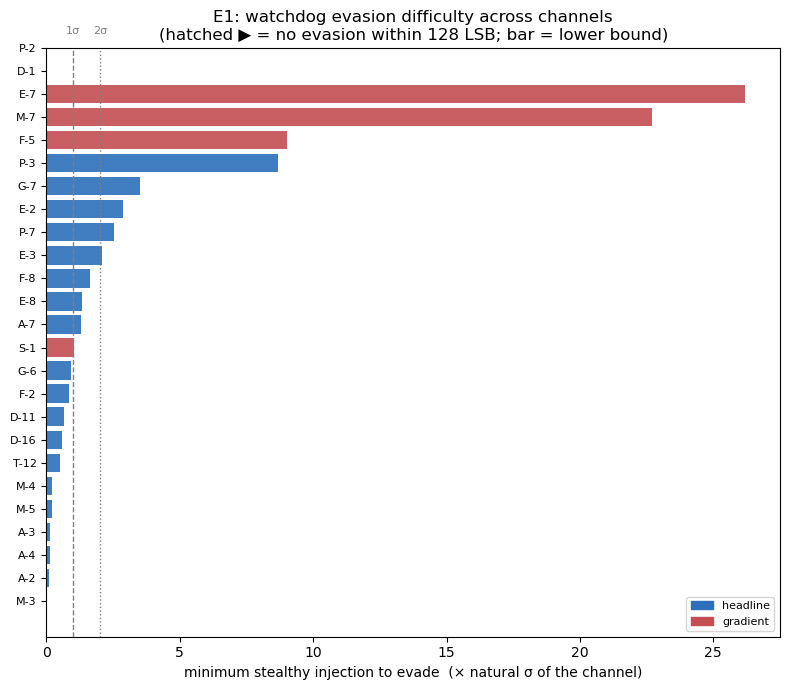

In [44]:
o = df.copy()
o["sig"] = o.apply(lambda r: r["minEvas_in_σ"] if r["minEvas_LSB"] is not None else (128.0/r["clean_σ_LSB"] if r["clean_σ_LSB"]>0 else np.nan), axis=1)
o["robust"] = o["minEvas_LSB"].isna()
o = o.sort_values("sig").reset_index(drop=True)
base = {"headline":"#2c6fbb", "gradient":"#c44e52"}
cols = [(*mcolors.to_rgb(base[s]), 0.45 if rb else 0.9) for s,rb in zip(o["stratum"], o["robust"])]
fig, ax = plt.subplots(figsize=(8, 7)); y = np.arange(len(o))
bars = ax.barh(y, o["sig"], color=cols)
for bar, rb in zip(bars, o["robust"]):
    if rb: bar.set_hatch("//"); bar.set_edgecolor("black")
ax.set_yticks(y); ax.set_yticklabels(o["chan"], fontsize=8)
for xv,lab,ls in [(1,"1σ","--"),(2,"2σ",":")]:
    ax.axvline(xv, color="gray", ls=ls, lw=1); ax.text(xv, len(o)-0.4, lab, color="gray", ha="center", fontsize=8)
for i, rb in enumerate(o["robust"]):
    if rb: ax.text(o["sig"].iloc[i]+0.05, i, "▶", va="center", fontsize=9)
ax.set_xlabel("minimum stealthy injection to evade  (× natural σ of the channel)")
ax.set_title("E1: watchdog evasion difficulty across channels\n(hatched ▶ = no evasion within 128 LSB; bar = lower bound)")
ax.legend(handles=[Patch(color=base["headline"],label="headline"), Patch(color=base["gradient"],label="gradient")], loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

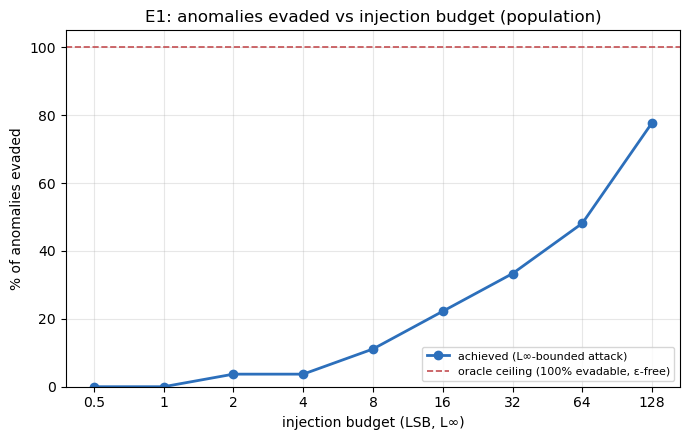

In [45]:
grid = sorted({t["eps"]/DLSB for d in results.values() for t in d["trials"] if t.get("phase")=="grid" and t.get("clean_hit")})
frac = []
for e in grid:
    h = [t["ceiling_missed"] for d in results.values() for t in d["trials"]
         if t.get("phase")=="grid" and t.get("clean_hit") and abs(t["eps"]/DLSB - e) < 1e-6]
    frac.append(np.mean(h) if h else 0.0)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid, np.array(frac)*100, "o-", color="#2c6fbb", lw=2, label="achieved (L∞-bounded attack)")
ax.axhline(100, color="#c44e52", ls="--", lw=1.2, label="oracle ceiling (100% evadable, ε-free)")
ax.set_xscale("log", base=2); ax.set_xticks(grid); ax.set_xticklabels([f"{e:g}" for e in grid])
ax.set_xlabel("injection budget (LSB, L∞)"); ax.set_ylabel("% of anomalies evaded"); ax.set_ylim(0,105)
ax.set_title("E1: anomalies evaded vs injection budget (population)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

/home/jovyan/work/SecureSpace/telemanom_reproduction/pipeline.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location="cpu")


M-3: evaded=True  L∞=12.0 LSB = 0.18σ
detect(clean) : [(1443, 1647)]
detect(perturbed): []


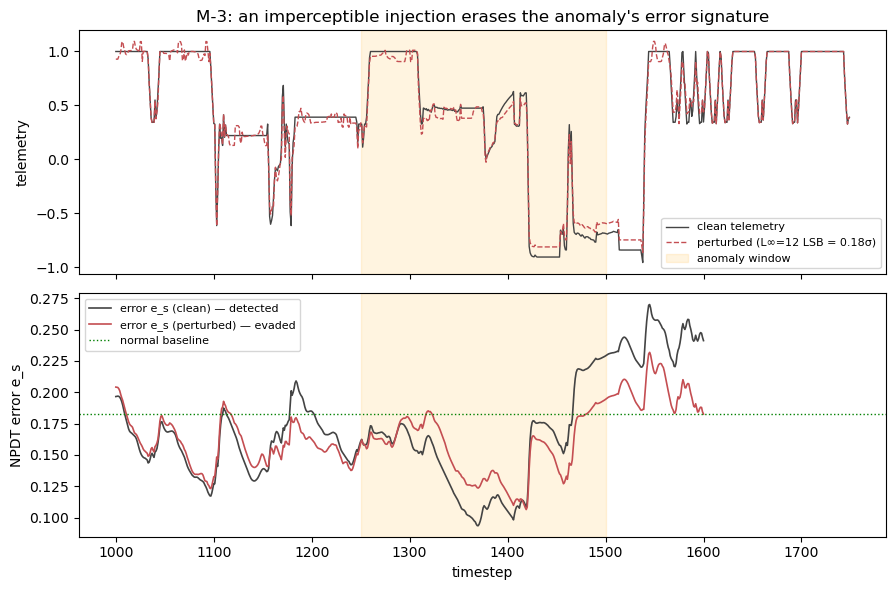

In [46]:
import torch
from fgsm_pgd_attacks import prepare_model, detect, AttackConfig, VendoredConfig, DEVICE
from pipeline import load_trained_model
from ceil_attack import ceiling_attack, CeilingConfig
cfg = VendoredConfig()
ccfg = CeilingConfig()
CHAN, BUDGET_LSB = "M-3", 12
tele, cmds, train_features, labels, T = load_streams(CHAN, DATA)
model = prepare_model(load_trained_model(RUNS / CHAN / "model.pt", n_features=train_features.shape[1], device=DEVICE))
label = labels[0]
res = ceiling_attack(CHAN, model, train_features, tele, cmds, labels, label, cfg, ccfg, float(BUDGET_LSB)*DLSB, return_delta=True)
delta = np.array(res["best_delta"]); tele_p = tele + delta
mask = (np.arange(T)<label[0]-100) | (np.arange(T)>label[1]+100)
sig = np.std(tele[mask])/DLSB; linf = np.max(np.abs(delta))/DLSB
print(f"{CHAN}: evaded={res['ceiling_missed']}  L∞={linf:.1f} LSB = {linf/sig:.2f}σ")
print("detect(clean) :", detect(CHAN, model, train_features, tele,   cmds, cfg))
print("detect(perturbed):", detect(CHAN, model, train_features, tele_p, cmds, cfg))
a, b = label; lo, hi = max(0,a-250), min(T,b+250)
es_c, es_p = np.array(res["es_clean"]), np.array(res["es_pert"])
xr = np.arange(len(es_c)) + res["es_R0"] + cfg.l_s; m = (xr>=lo)&(xr<hi)
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(range(lo,hi), tele[lo:hi], color="#444", lw=1.0, label="clean telemetry")
ax[0].plot(range(lo,hi), tele_p[lo:hi], color="#c44e52", lw=1.0, ls="--", label=f"perturbed (L∞={linf:.0f} LSB = {linf/sig:.2f}σ)")
ax[0].axvspan(a, b, color="orange", alpha=0.12, label="anomaly window")
ax[0].set_ylabel("telemetry"); ax[0].legend(fontsize=8)
ax[0].set_title(f"{CHAN}: an imperceptible injection erases the anomaly's error signature")
ax[1].plot(xr[m], es_c[m], color="#444", lw=1.2, label="error e_s (clean) — detected")
ax[1].plot(xr[m], es_p[m], color="#c44e52", lw=1.2, label="error e_s (perturbed) — evaded")
ax[1].axhline(res["baseline_b"], color="green", ls=":", lw=1, label="normal baseline")
ax[1].axvspan(a, b, color="orange", alpha=0.12)
ax[1].set_ylabel("NPDT error e_s"); ax[1].set_xlabel("timestep"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()